In [2]:
import requests
import pandas as pd
import numpy as np

def download_and_parse_hurdat2_fixed(url):
    print("Đang kết nối với máy chủ NOAA...")
    
    # "Ngụy trang" yêu cầu gửi đi giống như đang dùng trình duyệt Chrome/Windows
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    
    try:
        # Thêm timeout 15 giây để tránh treo máy. 
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()  # Báo lỗi ngay nếu link hỏng (lỗi 404, 403)
        
        print("Đã tải xong file gốc! Đang bóc tách dữ liệu...")
        lines = response.text.split('\n')
        
        data = []
        current_storm_id = ""
        current_storm_name = ""
        
        for line in lines:
            if not line.strip(): # Bỏ qua dòng trống
                continue
                
            parts = [p.strip() for p in line.split(',')]
            
            # Nhận diện dòng tiêu đề
            if len(parts) < 10:
                current_storm_id = parts[0]
                current_storm_name = parts[1]
            else:
                # Nhận diện dòng dữ liệu chi tiết
                data.append({
                    'Storm_ID': current_storm_id,
                    'Storm_Name': current_storm_name,
                    'Date': parts[0],
                    'Time_UTC': parts[1],
                    'Status': parts[3],
                    'Latitude': parts[4],
                    'Longitude': parts[5],
                    'Max_Wind_kt': int(parts[6]) if parts[6] != '-999' else np.nan,
                    'Min_Pressure_mb': int(parts[7]) if parts[7] != '-999' else np.nan
                })
                
        df = pd.DataFrame(data)
        print("Hoàn tất bóc tách!")
        return df
        
    except requests.exceptions.RequestException as e:
        print(f"Lỗi kết nối mạng hoặc bị chặn: {e}")
        return None

# Chạy thử lại
url_hurdat2 = "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2023-051124.txt" 
df_storms = download_and_parse_hurdat2_fixed(url_hurdat2)

if df_storms is not None:
    display(df_storms.head())

Đang kết nối với máy chủ NOAA...
Đã tải xong file gốc! Đang bóc tách dữ liệu...
Hoàn tất bóc tách!


,Storm_ID,Storm_Name,Date,Time_UTC,Status,Latitude,Longitude,Max_Wind_kt,Min_Pressure_mb
0,AL011851,UNNAMED,18510625,0000,HU,28.0N,94.8W,80,NaN
1,AL011851,UNNAMED,18510625,0600,HU,28.0N,95.4W,80,NaN
2,AL011851,UNNAMED,18510625,1200,HU,28.0N,96.0W,80,NaN
3,AL011851,UNNAMED,18510625,1800,HU,28.1N,96.5W,80,NaN
4,AL011851,UNNAMED,18510625,2100,HU,28.2N,96.8W,80,NaN


In [3]:
# Lưu data thành file CSV, bỏ qua cột số thứ tự (index)
df_storms.to_csv('hurdat2_data_sach.csv', index=False)
print("Đã lưu file thành công!")

Đã lưu file thành công!


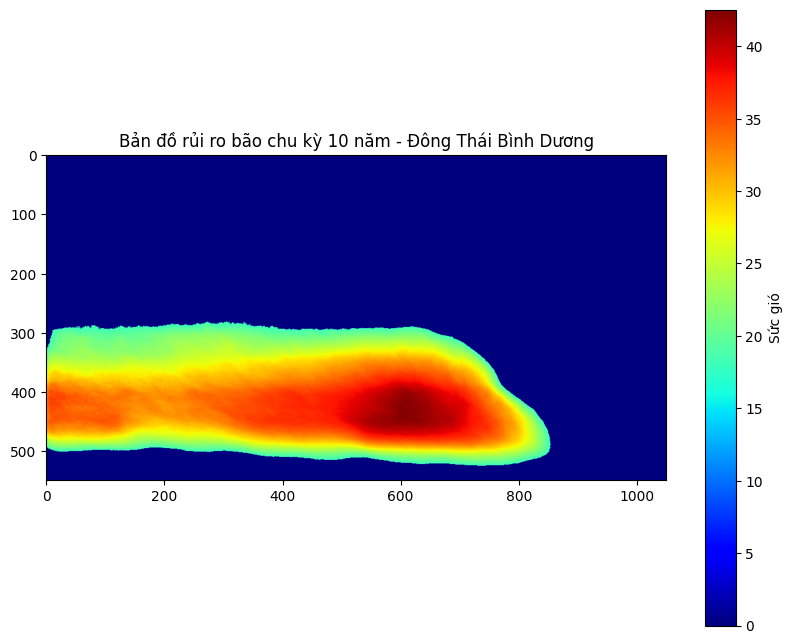

In [ ]:
import rasterio
import matplotlib.pyplot as plt

# Đường dẫn tới file tif của bro (Nhớ sửa lại đường dẫn nếu file nằm khác thư mục)
file_path = file_path = r"STORM tropical cyclone wind speed return periods_4_all/STORM_FIXED_RETURN_PERIODS_PRESENT_TIF/STORM_FIXED_RETURN_PERIODS_EP_20_YR_RP.tif"
# Mở và đọc file GeoTIFF
with rasterio.open(file_path) as src:
    # Đọc dải màu (band) đầu tiên chứa ma trận dữ liệu sức gió
    wind_data = src.read(1)
    
# Hiển thị ma trận số liệu lên thành một bản đồ trực quan
plt.figure(figsize=(10, 8))
# Dùng cmap='jet' để tạo dải màu nhiệt (đỏ là gió mạnh, xanh là gió yếu)
plt.imshow(wind_data, cmap='jet') 
plt.colorbar(label='Sức gió')
plt.title('Bản đồ rủi ro bão chu kỳ 10 năm - Đông Thái Bình Dương')
plt.show()

In [3]:
import xarray as xr

# Đường dẫn OPeNDAP đến file SST độ phân giải 1 độ của ICOADS (NOAA PSL)
url = "https://psl.noaa.gov/thredds/dodsC/Datasets/icoads/1degree/sst.mean.nc"

print("Đang kết nối tới máy chủ dữ liệu ICOADS...")
# Mở dataset trực tiếp từ web (chưa tải toàn bộ vào RAM, rất nhẹ)
ds = xr.open_dataset(url)

# Xem thông tin cấu trúc của bộ dữ liệu
print(ds)

# Lọc thử dữ liệu: Lấy nhiệt độ mặt biển toàn cầu vào tháng 8 năm 2023 (thời điểm mùa bão)
sst_aug_2023 = ds['sst'].sel(time='2023-08-01', method='nearest')

print("\n--- Dữ liệu Nhiệt độ mặt biển (SST) tháng 8/2023 ---")
print(sst_aug_2023)

Đang kết nối tới máy chủ dữ liệu ICOADS...


OSError: [Errno -77] NetCDF: Access failure: 'https://psl.noaa.gov/thredds/dodsC/Datasets/icoads/1degree/sst.mean.nc'